In [87]:
import pyrpl
from pyrpl import Pyrpl
from datetime import datetime
from time import sleep
import time
import numpy as np
import matplotlib.pyplot as plt
import types
import matplotlib.animation as animation
import matplotlib
import scipy
from numpy.typing import NDArray

from calibration.calibration import Calibrator

#Put in each relevant cell to allow for interactive plot rendering & animations
%matplotlib widget

plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 50
plt.rcParams['figure.constrained_layout.use'] = True

In [88]:
HOSTNAME = 'qifo-pitaya-1.local'
#HOSTNAME = '192.168.0.157'
PASSWORD = "L!g0bears"

calibrator = Calibrator(config_file = "calibration/pitaya1_calibration_go.json")

p = Pyrpl(config='', hostname=HOSTNAME, password=PASSWORD, gui=False)
rp = p.rp


INFO:pyrpl.redpitaya:Correct FPGA image detected, skipping reload
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname qifo-pitaya-1.local.


In [89]:

#Mostly relevant for faking refl_pd signal, besides modulation_freq which is used for demodulating the real signal
params = types.SimpleNamespace(
    modulation_freq = 15e6,
    sideband_depth = 1.08,
    decimation = 256
)

EOM_V_pi = 6.2 #How many volts induces a pi phase shift from the EOM
EOM_drive_voltage = EOM_V_pi * params.sideband_depth / np.pi

In [90]:
import pyrpl.hardware_modules

demod_iq = rp.iq0
piezo_asg = rp.asg0
scope = rp.scope
control_pid = rp.pid0
pid1 = rp.pid1
na = p.networkanalyzer

ports = types.SimpleNamespace(
    piezo = 'out1',
    refl_pd = 'in1',
    trans_pd = 'in2',
    local_oscillator = 'out2'
)


In [91]:
def lorentzian(x, A, B, g, x0):
    return (A / ((x-x0)**2 + g**2)) + B

def lorentzian_derivative(x, A, B, g, x0): #For lorentzian A / ((x-x0)^2 + g^2)
    return -2 * A * (x - x0) / (((x-x0)**2 + g**2)**2) + B

In [106]:
def set_iq(iq=demod_iq, frequency:float=params.modulation_freq, bandwidth:list=[0,0], acbandwidth:float=0, phase:float=0, amplitude:float=1.0,
                  gain:float=0, input:str='off', LO_output:str='off', output_signal:str='quadrature', quadrature_factor:float=1, calibrate_output:bool=False):
    iq.setup(frequency=frequency, bandwidth = bandwidth, acbandwidth = acbandwidth, gain = gain, phase = phase, amplitude = amplitude, input = input,
                output_direct = LO_output, output_signal = output_signal, quadrature_factor = quadrature_factor)
    if(calibrate_output):
        iq.amplitude = calibrator.correct_output(LO_output, amplitude)

def set_demodulator(frequency:float=params.modulation_freq, bandwidth:list=[10e3,20e3], acbandwidth:float=50000, phase:float=0, amplitude:float=0.98,
                  gain:float=0, input:str=ports.refl_pd, LO_output:str=ports.local_oscillator, output_signal:str='quadrature', quadrature_factor:float=1, calibrate_output:bool=False):
    set_iq(iq=demod_iq, frequency=frequency, bandwidth = bandwidth, acbandwidth = acbandwidth, gain = gain, phase = phase, amplitude = amplitude, input = input,
            LO_output = LO_output, output_signal = output_signal, quadrature_factor = quadrature_factor, calibrate_output=calibrate_output)
    

def set_asg(asg = piezo_asg, output: str = ports.piezo, waveform:str = 'dc', frequency:float=1e0, amplitude:float = 1, offset:float = 0, calibrate_output:bool=False):
    if(calibrate_output):
        offset = calibrator.correct_output(output, offset)
        amplitude = calibrator.correct_output(output, amplitude)
    asg.setup(waveform=waveform, output_direct=output, offset=offset, amplitude=amplitude, frequency=frequency, trigger_source='immediately')
    


def start_piezo_scan(output: str = ports.piezo, frequency: float = 1e0, amplitude: float = 0.5, offset:float = 0.5):
    set_asg(asg = piezo_asg, waveform = 'ramp', output=output, frequency=frequency, amplitude=amplitude, offset=offset)


def take_scan_trace(decimation: int = 256, input1:str=ports.piezo, input2:str=demod_iq.name) -> list:
    scope.decimation = decimation

    scope.input1 = input1
    scope.input2 = input2

    scope.threshold = piezo_asg.offset #+ piezo_asg.amplitude / 2 #Trigger on rising edge of piezo ramp
    scope.hysteresis = 0.01

    scope.trigger_source = 'ch1_positive_edge'
    scope.trigger_delay = 0

    return scope.single()

def take_immediate_scope_trace(decimation: int = 256, input1:str="in1", input2:str="in2") -> list:
    # Scope samples at rate of 125 MHz, aka 1 sample per 1 / (125*10^6) = 8 * 10^-9 seconds
    # With decimation, it fills one data point per {decimation} samples, and the scope trace holds 2^14 samples
    # Thus scope traces / second = (trace / data point) * (1 data point / {decimation} samples) * (1 sample / 8*10^-9 seconds)
    # So the period of one scope trace is T = 8 * 10^-9 * 2^14 * {decimation} seconds

    scope.decimation = decimation

    scope.input1 = input1
    scope.input2 = input2

    scope.threshold = 0
    scope.hysteresis = 0.0

    scope.trigger_source = 'immediately'
    scope.trigger_delay = 0

    return scope.single()

    
def set_pid(pid = control_pid, ival: float = 0, integrator: float = 1e3, proportional: float = 0, input:str=demod_iq.name, output_direct:str=ports.piezo, setpoint:float=0):
    pid.setup(input=input, output_direct=output_direct, p=proportional, i=integrator, setpoint=setpoint)
    pid.ival = ival


def get_spectrum(input1: str = 'off', input2: str = 'off', span: float = 1e6, acbandwidth:float=0, window:str='blackman') -> tuple[NDArray, NDArray, NDArray]:
    p.spectrumanalyzer.setup(input1_baseband=input1, input2_baseband=input2, baseband=True, span=span, window=window)

    ch1, ch2, cross_re, cross_im = p.spectrumanalyzer.single()

    return p.spectrumanalyzer.frequencies, ch1, ch2


def get_transfer_function(output:str="off",input:str="off",points:int=200,acbandwidth:float=0,trace_average:int=1,average_per_point:int=1,
                          start_freq:float=1e3,stop_freq:float=1e6,resolution_bandwidth:float=100,auto_bandwidth:bool=False,amplitude:float=0.1):
    na.output_direct = output
    na.input = input
    na.acbandwidth = acbandwidth # High pass filtering before demodulation
    na.logscale = True
    na.trace_average = trace_average
    na.average_per_point = average_per_point
    na.points = points
    na.start_freq = start_freq
    na.stop_freq = stop_freq

    # adapt the resolution bandwidth so the q=rbw/frequency ratio stays constant
    na.auto_bandwidth = auto_bandwidth
    #na.q_factor_min = 10              # min value of the q=rbw/frequency ratio
    na.rbw = resolution_bandwidth                               # Starting resolution bandwidth value

    na.amplitude = amplitude
    # adapt output amplitude to keep input around target_dbv and avoid saturation
    # na.auto_amplitude = False
    # na.target_dbv = -20
    # na.auto_amp_min = 0.001                      # min value of the amplitude
    # na.auto_amp_max = 0.5

    freqs = na.frequencies
    transfer_func = na.single()                 # complex response values

    return freqs, transfer_func



def reset_modules():
    set_asg(asg = rp.asg0, output='off', offset=0, amplitude=0)
    set_asg(asg = rp.asg1, output='off', offset=0, amplitude=0)

    set_iq(iq = rp.iq0, LO_output = 'off', output_signal = 'off', amplitude = 0, quadrature_factor = 0)
    set_iq(iq = rp.iq1, LO_output = 'off', output_signal = 'off', amplitude = 0, quadrature_factor = 0)
    set_iq(iq = rp.iq2, LO_output = 'off', output_signal = 'off', amplitude = 0, quadrature_factor = 0)

    set_pid(rp.pid0, ival=0, integrator=0, proportional=0, input='off', output_direct='off')
    set_pid(rp.pid1, ival=0, integrator=0, proportional=0, input='off', output_direct='off')
    set_pid(rp.pid2, ival=0, integrator=0, proportional=0, input='off', output_direct='off')
    

In [107]:
def draw_bode_plot(freqs, transfer_func):
    amplitudes_db = 20 * np.log10(np.abs(transfer_func))
    phases = np.angle(transfer_func, deg=True)


    bode_fig, bode_axs = plt.subplots(2)

    bode_axs[0].grid(which='both')
    bode_axs[1].grid(which='both')


    bode_axs[0].set_xscale('log')
    bode_axs[0].set_ylabel("Magnitude [dB]")
    #bode_axs[0].set_yscale('log')
    #bode_axs[0].xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))
    bode_axs[0].scatter(freqs, amplitudes_db, color = 'indigo', s = 2, edgecolors = 'none')
    bode_axs[0].plot(freqs, amplitudes_db, color = 'indigo', linewidth = 1)

    bode_axs[1].set_xscale('log')
    bode_axs[1].set_xlabel("Frequency [Hz]")
    bode_axs[1].set_ylabel("Phase [deg]")
    bode_axs[1].scatter(freqs, phases, color = 'blue', s = 2, edgecolors = 'none')
    bode_axs[1].plot(freqs, phases, color = 'blue', linewidth = 1)

    return bode_fig, bode_axs

def plot_LO_power_spectrum(num_divisions: int = 200, sleep_time = 0.001, LO_output='out2', LO_input='out2', randomize_sample_order = False):
    power_proportions = np.zeros(num_divisions)
    LO_amplitudes = np.linspace(0.95, 1.02, num_divisions)
    if(randomize_sample_order): np.random.shuffle(LO_amplitudes)

    demod_iq.output_direct = LO_output

    for i in range(num_divisions):
        demod_iq.amplitude = LO_amplitudes[i]

        sleep(sleep_time)

        LO_spectrum_freqs, LO_spectrum_powers = get_spectrum(input1=LO_input, span=params.modulation_freq * 3)

        sleep(sleep_time)

        modulation_freq_index = np.argmin(np.abs(LO_spectrum_freqs - params.modulation_freq))
        frequency_spacing = (np.max(LO_spectrum_freqs) - np.min(LO_spectrum_freqs)) / len(LO_spectrum_freqs)

        lower_bound_freq = 0.999 * params.modulation_freq
        upper_bound_freq = 1.001 * params.modulation_freq

        lower_bound_index = int(lower_bound_freq / frequency_spacing)
        upper_bound_index = int(upper_bound_freq / frequency_spacing)

        peak_indices, __ = scipy.signal.find_peaks(LO_spectrum_powers, threshold=1e-100, prominence=1e-10, distance=100)

        total_spectrum_power = scipy.integrate.simpson(LO_spectrum_powers, LO_spectrum_freqs)

        modulation_spectrum_power = scipy.integrate.simpson(LO_spectrum_powers[lower_bound_index:upper_bound_index], LO_spectrum_freqs[lower_bound_index:upper_bound_index])

        power_proportions[i] = 100 * modulation_spectrum_power / total_spectrum_power

    spectrum_fig, spectrum_ax = plt.subplots(1, figsize=(8,6))

    spectrum_ax.scatter(LO_amplitudes, power_proportions, s=4, edgecolors='none', color='blue')

    spectrum_ax.plot(LO_amplitudes, power_proportions, linewidth=0.5, color='slateblue', zorder=-1)


    spectrum_ax.set_xlabel("Amplitude (V)")
    spectrum_ax.set_ylabel(f"Percent of power within {lower_bound_freq*1e-6:0.2f}--{upper_bound_freq*1e-6:0.2f} MHz")

    spectrum_fig.savefig('LO_spectrum.png')


In [108]:
def lock_cavity(demod_phase: float = 0, p:float = 0, i: float = 0, plot_scan_data: bool = True, quadrature_factor:float = 1):
    reset_modules()
    set_demodulator(phase=demod_phase, quadrature_factor=quadrature_factor, amplitude=0.98, LO_output='off')

    print("Scanning piezo")
    start_piezo_scan(output=ports.piezo, frequency = 0.5 * (1 / (8e-9 * params.decimation * 2**14))) #Cover half the period in the time it takes for scope to trace

    print("Taking scope traces")
    pdh_signal_scope_trace = take_scan_trace(decimation = params.decimation, input1 = ports.piezo, input2 = demod_iq.name)
    trans_pd_scope_trace = take_scan_trace(decimation = params.decimation, input1 = ports.piezo, input2 = ports.trans_pd)
    refl_pd_scope_trace = take_scan_trace(decimation = params.decimation, input1 = ports.piezo, input2 = ports.refl_pd)
    print("Done taking scope traces!")

    pdh_scan_ch1, pdh_scan_ch2 = pdh_signal_scope_trace  #ch1 = piezo, ch2 = pdh signal
    trans_pd_scan_ch1, trans_pd_scan_ch2 = trans_pd_scope_trace #ch1 = piezo, ch2 = trans_pd
    refl_pd_scan_ch1, refl_pd_scan_ch2 = refl_pd_scope_trace

    #pdh_scan_ch2, trans_pd_scan_ch2 = dual_scope_trace
    #pdh_scan_ch1 = np.linspace(0, 1, pdh_scan_ch2.size)
    #trans_pd_scan_ch1 = np.linspace(0, 1, pdh_scan_ch2.size)

    scan_fit_axs, scan_fit_plot = None, None
    
    if(plot_scan_data == True):
        scan_fit_plot, scan_fit_axs = plt.subplots(3, figsize=(6,6))

        scan_fit_axs[0].set_xlim(pdh_scan_ch1.min(), pdh_scan_ch1.max())
        
        scan_fit_axs[0].set_title("PDH Error Signal Over Piezo Scan")
        scan_fit_axs[0].set_xlabel("PZT Drive Voltage (V)")
        scan_fit_axs[0].set_ylabel("Error Signal (V)")
        scan_fit_axs[0].grid(True)
        
        scan_fit_axs[0].scatter(pdh_scan_ch1, pdh_scan_ch2, color='blue', s=1, edgecolors='none')
        scan_fit_axs[0].plot(pdh_scan_ch1, pdh_scan_ch2, color='blue', linewidth=1)
        
        scan_fit_axs[1].set_title("Trans_PD Signal Over Piezo Scan")
        scan_fit_axs[1].set_xlabel("PZT Drive Voltage (V)")
        scan_fit_axs[1].set_ylabel("Trans_PD Signal (V)")
        scan_fit_axs[1].grid(True)


        scan_fit_axs[1].scatter(trans_pd_scan_ch1, trans_pd_scan_ch2, color='blue', s=0.5, edgecolors='none')
        scan_fit_axs[1].plot(trans_pd_scan_ch1, trans_pd_scan_ch2, color = 'blue', linewidth=1)


        scan_fit_axs[2].set_title("Refl_PD Signal Over Piezo Scan")
        scan_fit_axs[2].set_xlabel("PZT Drive Voltage (V)")
        scan_fit_axs[2].set_ylabel("Refl_PD Signal (V)")
        scan_fit_axs[2].grid(True)

        scan_fit_axs[2].scatter(refl_pd_scan_ch1, refl_pd_scan_ch2, color='blue', s=0.5, edgecolors='none')
        scan_fit_axs[2].plot(refl_pd_scan_ch1, refl_pd_scan_ch2, color = 'blue', linewidth=1)

    fit_success = True
    #trans_peak_index = np.argmax(trans_pd_scan_ch2)

    gradients = np.gradient(pdh_scan_ch2)
    trans_peak_index = np.argmax(np.abs(gradients))

    try:
        print("Trying curve fit")
        # Guess Initial Parameters (taken from edofazza)
        x0_guess = pdh_scan_ch1[trans_peak_index]
        B_guess = np.mean(pdh_scan_ch2)
        g_guess = (np.max(pdh_scan_ch1) - np.min(pdh_scan_ch1)) / 20
        A_guess = (np.max(pdh_scan_ch2) - np.mean(pdh_scan_ch2)) * -0.5 * np.sqrt(256/27) * g_guess**3


        window_fraction = 0.03
        lower_idx = max(0, int(trans_peak_index - 16384 * window_fraction))
        upper_idx = min(len(trans_pd_scan_ch1) - 1, int(trans_peak_index + 16384 * window_fraction))

        if(plot_scan_data == True):
            scan_fit_axs[0].axvline(pdh_scan_ch1[lower_idx], color = 'red', linewidth = 1)
            scan_fit_axs[0].axvline(pdh_scan_ch1[upper_idx], color = 'red', linewidth = 1)


        pdh_popt, pdh_pcov = scipy.optimize.curve_fit(lorentzian_derivative, pdh_scan_ch1[lower_idx:upper_idx], pdh_scan_ch2[lower_idx:upper_idx], p0=[A_guess, B_guess, g_guess, x0_guess]) #pdh_popt = [A, B, g, x0]
        trans_popt, trans_pcov = scipy.optimize.curve_fit(lorentzian, trans_pd_scan_ch1[lower_idx:upper_idx], trans_pd_scan_ch2[lower_idx:upper_idx]) #trans_popt = [A, B, g, x0]

        if(plot_scan_data == True):
            scan_fit_axs[0].scatter(pdh_scan_ch1[lower_idx:upper_idx], lorentzian_derivative(pdh_scan_ch1[lower_idx:upper_idx], *pdh_popt), color='red', s=1, edgecolors='none')
            scan_fit_axs[1].scatter(trans_pd_scan_ch1[lower_idx:upper_idx], lorentzian(trans_pd_scan_ch1[lower_idx:upper_idx], *trans_popt), color='red', s=1, edgecolors='none')

    except RuntimeError:
        pdh_popt = np.array([0, 0, 0, 0])
        trans_popt = np.array([0,0, 0, 0])
        print("Fit failed")
        fit_success = False
    
    
    resonance_voltage = pdh_popt[3]
    resonance_voltage = trans_pd_scan_ch1[trans_peak_index]
    peak_trans_pd_signal = trans_pd_scan_ch2[trans_peak_index]
    setpoint = 0#pdh_popt[1]
    
    print(f"Moving piezo to resonance at voltage {resonance_voltage} V and setpoint {setpoint}")

    if(plot_scan_data):
        scan_fit_axs[0].scatter(resonance_voltage, setpoint, s = 10, color='red', edgecolors='none')
        scan_fit_plot.savefig("scan.png", dpi = 200)

    set_asg(piezo_asg, waveform='dc', output=ports.piezo, offset=resonance_voltage)

    print("Starting PID loop")

    set_pid(control_pid, setpoint = setpoint, proportional = p, integrator = i)

    return fit_success, scan_fit_plot, scan_fit_axs, peak_trans_pd_signal
    

def auto_relock(demod_phase: float = 0, p:float = 0, i: float = 0, quadrature_factor:float = 1):
    reset_modules()
    __, ___, ____, peak_trans_pd_signal = lock_cavity(demod_phase=demod_phase, p=p, i=i, plot_scan_data=False, quadrature_factor=quadrature_factor)
    
    starting_time = time.time()
    print(f"Locked at: {time.strftime("%I:%M:%S", time.localtime(starting_time))}")

    
    try:
        while True:
            time.sleep(10)
            print(f"Seconds after start: {(time.time() - starting_time):0.2f}")

            ch1, ch2 = take_immediate_scope_trace(input1 = ports.piezo, input2 = ports.trans_pd)

            print(f"Signal to piezo mean: {ch1.mean()}")
            print(f"Trans PD mean: {ch2.mean()}")
            print(f"Trans PD peaks: {peak_trans_pd_signal}, {ch2.max()}")
            print(f"Trans PD mean to peak fraction: {ch2.mean() / peak_trans_pd_signal}")
            print(f"Control PID output voltage: {control_pid.current_output_signal}")

            if(ch2.mean() / peak_trans_pd_signal < 0.7 or np.abs(control_pid.current_output_signal) > 0.05):
                end_time = time.time()
                print(f"Lost lock at: {time.strftime("%I:%M:%S", time.localtime(end_time))}. Lasted {(end_time - starting_time):0.2f} seconds")
                print("---------------------------------------")
                break
            else:
                print("----")
    except KeyboardInterrupt:
        print("Loop broken!")
        return
    auto_relock(demod_phase=demod_phase, p=p, i=i, quadrature_factor=quadrature_factor)



In [133]:
reset_modules()


In [134]:
#start_piezo_scan(output=ports.piezo, frequency = 30)


In [135]:
print(na.setup_attributes)

OrderedDict({'trace_average': 1, 'curve_name': 'networkanalyzer curve', 'run_continuous': False, 'input': 'in2', 'output_direct': 'out2', 'acbandwidth': 0, 'start_freq': 10.0, 'stop_freq': 20000.0, 'rbw': np.float64(75.89113552886508), 'average_per_point': 1, 'points': 200, 'amplitude': 0.09999847412109375, 'logscale': True, 'auto_bandwidth': False, 'q_factor_min': 10, 'auto_amplitude': False, 'target_dbv': -80, 'auto_amp_min': 0.0001, 'auto_amp_max': 1.0})


Scanning piezo
Taking scope traces
Done taking scope traces!
Trying curve fit
Moving piezo to resonance at voltage 0.636962890625 V and setpoint 0
Starting PID loop


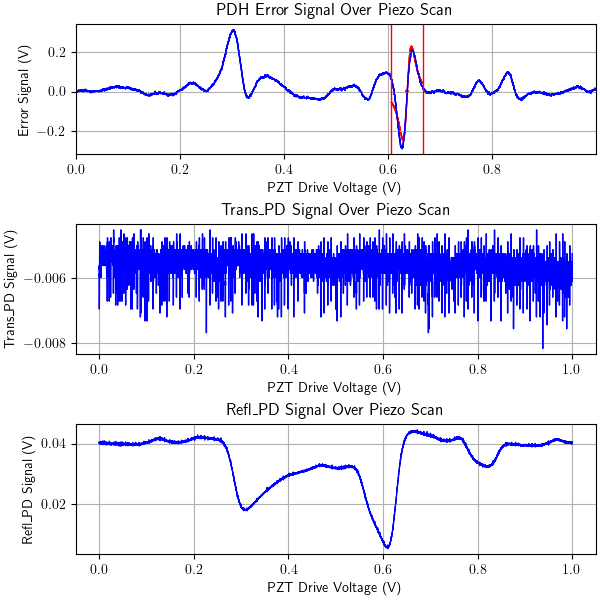

In [151]:
_, lockfig, lockax, ____ = lock_cavity(demod_phase = 85, p = 0.0, i = -5, quadrature_factor=500)

# #auto_relock(demod_phase = 0, p = 0.01, i = 5.0, quadrature_factor=50)

# #lockfig.savefig("8-11_lock_test.png", dpi=200)

In [137]:
#set_pid(pid=pid1, integrator=0, proportional=1, input=demod_iq.name, output_direct = ports.local_oscillator)

#freqs, tf = get_transfer_function(output=ports.local_oscillator, input=ports.trans_pd, amplitude=0.1, start_freq=1e1, stop_freq=20e3, resolution_bandwidth=100)


In [138]:
#bodefig, bodeaxs = draw_bode_plot(freqs, tf)

In [139]:
# freqs, refl_spectrum, demod_spectrum = get_spectrum(input1 = ports.refl_pd, input2 = demod_iq.name, span=50e3)
# mW_per_volt = 3.21285140562

# spectrum_fig, spectrum_ax = plt.subplots(1)
# refl_db = 10 * np.log10(refl_spectrum * mW_per_volt)

# spectrum_ax.plot(freqs, refl_db)